## BIH_v5_run4

- Retrain from Big Earth Net (256px)
- 

### Importing required packages

In [1]:
import warnings
warnings.filterwarnings("ignore", category=UserWarning)
# from aitlas.datasets import TiiLIDARDatasetSegmentation
import torch
from aitlas.models import HRNet
from torch import nn
from stone_dataset import StoneDatasetSegmentation
import matplotlib.pyplot as plt

### Loading train, validation and test data

Input parameters for train, validation and test data:

- **batch_size**: The number of samples processed before the model is updated. A larger batch size can speed up processing but requires more memory.
- **num_workers**: The number of worker processes that will be used for processing data. Increasing the number of workers can significantly speed up data processing, however, it also increases memory and CPU/GPU usage.
- **object_class**: A parameter that specifies the type of archaeological object you are interested in processing, e.g., 'AO', 'barrow', 'enclosure', 'ringfort'.
- **object_class_band_id**: An integer parameter identifying the band where the annotations for a specific object class are located within the segmentation masks.
- **visualisation_type**: The vizuelization type used for the patches, e.g., 'SLRM'.
- **DFM_quality**: List of annotation qualities to be included in the processed data, e.g., '1,2'.
- **keep_empty_patches**: A boolean parameter that controls if empty patches are kept. Set to False when training since "empty" data can't be used for training. For testing or validation, True can be used to check how the model handles empty patches.
- **shuffle**: Determines whether the data should be shuffled before being processed. 
- **data_dir**: The directory path where the input data is stored. 
- **annotations_dir**: The directory path where the segmentation masks are stored. 
- **transforms**: A list of transformations applied to the input data during processing.
- **target_transforms**: A list of transformations applied to the segmentation masks during processing.
- **joint_transforms**: Transformations applied simultaneously to both the input data and segmentation masks.

In [2]:
batch_size = 8
num_workers = 2
object_class = "barrow"
object_class_band_id = 0 
visualisation_type = "SLRM"

# Stone DATA
train_data = r"r:\ML podatki\learning_samples\training_samples_BiH_v5_256px\train\images"
train_mask = r"r:\ML podatki\learning_samples\training_samples_BiH_v5_256px\train\segmentation_masks"

validation_data = r"r:\ML podatki\learning_samples\training_samples_BiH_v5_256px\val\images"
validation_mask = r"r:\ML podatki\learning_samples\training_samples_BiH_v5_256px\val\segmentation_masks"

test_data = r"r:\ML podatki\learning_samples\training_samples_BiH_v5_256px\test\images"
test_mask = r"r:\ML podatki\learning_samples\training_samples_BiH_v5_256px\test\segmentation_masks"

In [3]:
train_dataset_config = {
    "batch_size": batch_size,
    "num_workers": num_workers,
    "object_class": object_class,
    "object_class_band_id": object_class_band_id,
    "visualisation_type": visualisation_type,
    "DFM_quality": '1',
    "shuffle": True,
    "keep_empty_patches": False,
    "data_dir": train_data,
    "annotations_dir": train_mask,
    "joint_transforms": ["aitlas.transforms.FlipHVRandomRotate"],
    "transforms": ["aitlas.transforms.Transpose"],
	"target_transforms": ["aitlas.transforms.Transpose"]
}
train_dataset = StoneDatasetSegmentation(train_dataset_config)

validation_dataset_config = {
    "batch_size": batch_size,
    "num_workers": num_workers,
    "object_class": object_class,
    "object_class_band_id": object_class_band_id,
    "visualisation_type": visualisation_type,
    "DFM_quality": '1',
    "shuffle": False,
    "keep_empty_patches": False,
    "data_dir": validation_data,
    "annotations_dir": validation_mask,
    "transforms": ["aitlas.transforms.Transpose"],
    "target_transforms": ["aitlas.transforms.Transpose"]
}
validation_dataset = StoneDatasetSegmentation(validation_dataset_config)

test_dataset_config = {
    "batch_size": batch_size,
    "num_workers": num_workers,
    "object_class": object_class,
    "object_class_band_id": object_class_band_id,
    "visualisation_type": visualisation_type,
    "DFM_quality": '1',
    "shuffle": False,
    "keep_empty_patches": False,
    "data_dir": test_data,
    "annotations_dir": test_mask,
    "transforms": ["aitlas.transforms.Transpose"],
	"target_transforms": ["aitlas.transforms.Transpose"]
}
test_dataset = StoneDatasetSegmentation(test_dataset_config)

all_im = (len(train_dataset) + len(validation_dataset) + len(test_dataset))
print([len(train_dataset), len(validation_dataset), len(test_dataset)])
print([len(train_dataset)/all_im, len(validation_dataset)/all_im, len(test_dataset)/all_im])

[7048, 2730, 2797]
[0.5604771371769384, 0.21709741550695824, 0.2224254473161034]


Inspect if data was loaded correctly

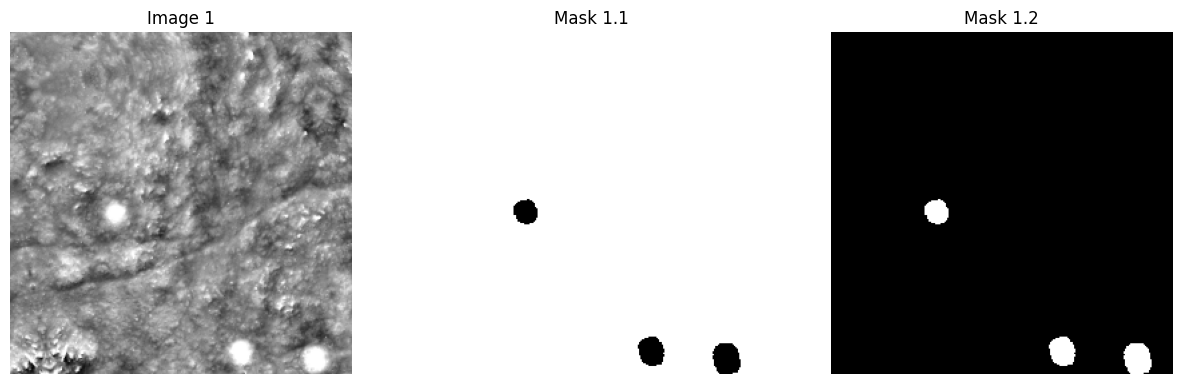

In [4]:
import rasterio
with rasterio.open(train_dataset.images[55]) as src:
    arr = src.read()

id_for_inspection = 55

stone_tensor = train_dataset.__getitem__(id_for_inspection)

plt.figure(figsize=(15, 10))

# --- Row 1 ---
plt.subplot(1, 3, 1)
plt.imshow(stone_tensor[0].permute(1, 2, 0).detach().cpu().numpy())
plt.title("Image 1")
plt.axis("off")

plt.subplot(1, 3, 2)
plt.imshow(stone_tensor[1][0].cpu().numpy(), cmap='gray')
plt.title("Mask 1.1")
plt.axis("off")

plt.subplot(1, 3, 3)
plt.imshow(stone_tensor[1][1].cpu().numpy(), cmap='gray')
plt.title("Mask 1.2")
plt.axis("off")

plt.show()

### Model creation

In [6]:
torch.cuda.empty_cache()        # releases *cached* memory to the allocator
torch.cuda.ipc_collect()        # cleans up interprocess memory references

# Some model parameters are fixed and can be loaded from the class
model_config = StoneDatasetSegmentation.get_fixed_model_config()

model = HRNet(model_config)
# model.model = nn.DataParallel(model.model)
model.prepare()

2025-12-09 17:04:08,795 INFO Loading pretrained weights from Hugging Face hub (timm/hrnet_w48.ms_in1k)
2025-12-09 17:04:08,976 INFO HTTP Request: HEAD https://huggingface.co/timm/hrnet_w48.ms_in1k/resolve/main/model.safetensors "HTTP/1.1 302 Found"
2025-12-09 17:04:08,978 INFO [timm/hrnet_w48.ms_in1k] Safe alternative available for 'pytorch_model.bin' (as 'model.safetensors'). Loading weights using safetensors.


### Loading pretrained ADAF model (optional)

If you don't want to use an existing model, you can skip this step. If you do want to use one, set the model path, uncomment the lines, and run the cell to load the model into memory.

In [6]:
#model_path = r"d:\nejc\adaf-main\adaf\ml_models\barrow_HRNet_SLRM_512px_pretrained_train_12_val_124_with_Transformation.tar" 
#model.load_model(model_path)

### Training the model

Input parameters: 
- **epochs**: The total number of training cycles the model will undergo. Each epoch represents one complete pass of the training dataset through the model.
- **model_directory**: Path to the directory where the trained model and its checkpoints will be saved. This is used for storing the model during and after training.
- **run_id**: Name of the subdirectory within the model_directory to store results from different runs

In [9]:
epochs = 30
model_directory = r"r:\delovno\nejc\models\BIH_retrain"
run_id = 'BIH_v5_run4'

In [ ]:
model.train_and_evaluate_model(
    train_dataset=train_dataset,
    val_dataset=validation_dataset,
    epochs=epochs,
    model_directory=model_directory,
    run_id=run_id
);

2025-12-09 17:05:00,161 INFO Starting training.
training:   5%|███▌                                                                   | 44/881 [01:23<19:34,  1.40s/it]

### Model evaluation

In [ ]:
torch.cuda.empty_cache()        # releases *cached* memory to the allocator
torch.cuda.ipc_collect()        # cleans up interprocess memory references

# Some model parameters are fixed and can be loaded from the class
model_config = StoneDatasetSegmentation.get_fixed_model_config()

model = HRNet(model_config)
# model.model = nn.DataParallel(model.model)

model.prepare()

model.running_metrics.reset()

model_path = r"r:\delovno\nejc\models\BIH_retrain\checkpoint.pth.tar" # update the path!
model.evaluate(dataset=test_dataset, model_path=model_path)

model.running_metrics.get_scores(model.metrics)